# LCM Training Monitor

This notebook provides tools to monitor the training progress of the LCM model and perform inference.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

## Training Metrics Visualization

In [2]:
def load_metrics(csv_path: str) -> pd.DataFrame:
    """Load training metrics from CSV file."""
    metrics_df = pd.read_csv(csv_path)
    metrics_df["lr-AdamW"] = metrics_df["lr-AdamW"].ffill()

    metrics_df = metrics_df[metrics_df["train_loss"].notna() + metrics_df["val_loss"].notna()]
    metrics_df = metrics_df.groupby("epoch").mean()

    metrics_df = metrics_df.reset_index()

    return metrics_df

In [34]:
def plot_metrics(metrics_df: pd.DataFrame) -> None:
    """Plot training metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(metrics_df["epoch"], metrics_df["train_loss"], label="Train Loss")
    ax1.plot(metrics_df["epoch"], metrics_df["val_loss"], label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_ylim(0.30, 0.8)
    ax1.set_title("Training and Validation Loss")
    ax1.legend()
    ax1.grid(True)

    # Plot learning rate
    ax2.plot(metrics_df["epoch"], metrics_df["lr-AdamW"], label="Learning Rate")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

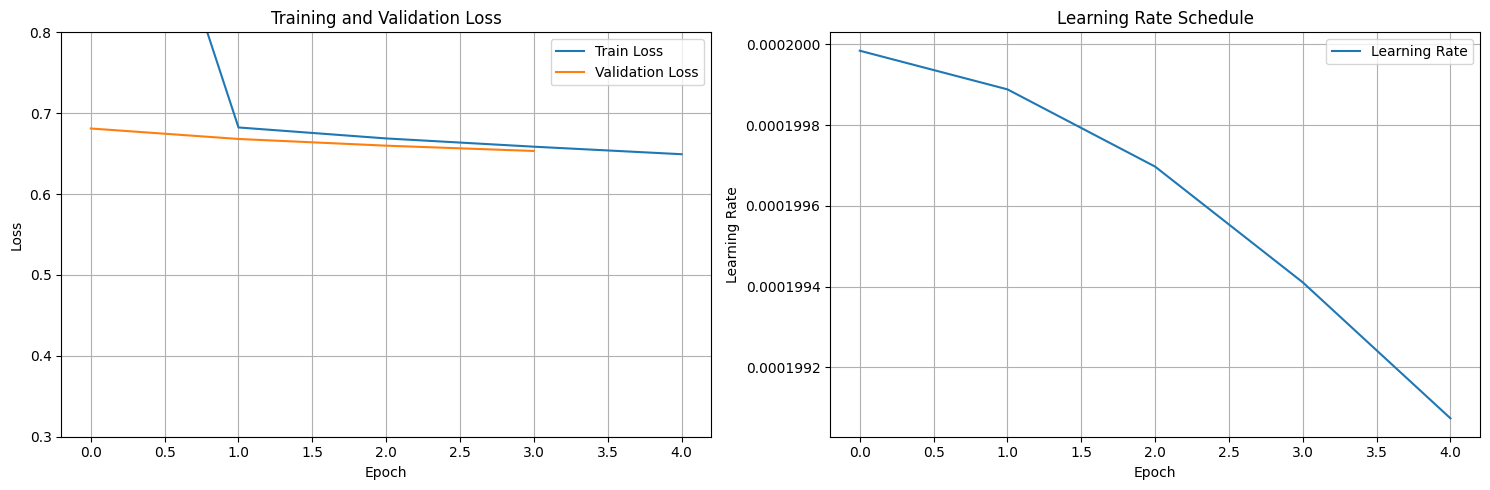

In [35]:
metrics_path = "/home/yannhallouard/PycharmProjects/large_concept_model/lightning_logs/version_8/metrics.csv"
metrics_df = load_metrics(metrics_path)

plot_metrics(metrics_df)

## Model Inference

This section allows you to load a trained model and perform inference on new text.

In [22]:
from lcm_explo.adapters.embedding_repository.file_system import FileSystemEmbeddingRepository
from lcm_explo.domain.models.base_lcm import BaseLCM, BaseLCMConfig
from lcm_explo.domain.usecases.train import BaseLCMTrainingModule

In [30]:
def generate_next_concepts(model: BaseLCM, input_embeddings: torch.Tensor, num_steps: int = 10) -> torch.Tensor:
    """Generate next concepts using the model."""
    device = next(model.parameters()).device

    # Move input to same device as model
    input_embeddings = input_embeddings.to(device)

    # Generate next concepts
    with torch.no_grad():
        current_sequence = input_embeddings
        generated_sequence = [current_sequence]

        for _ in range(num_steps):
            # Get next concept prediction
            padding_mask = torch.ones(current_sequence.shape[0]).to(device)
            next_concept = model(current_sequence, padding_mask)

            # Update sequence
            current_sequence = torch.cat([current_sequence[:, 1:], next_concept[:, -1:]], dim=1)
            generated_sequence.append(next_concept[:, -1:])

    return torch.cat(generated_sequence, dim=1)

In [65]:
checkpoint_path = "data/checkpoints/lcm-epoch=49-val_loss=0.4127.ckpt"
config = BaseLCMConfig()
model = BaseLCMTrainingModule.load_from_checkpoint(
    checkpoint_path,
)

In [66]:
# Load some example embeddings
embeddings_repo = FileSystemEmbeddingRepository(base_path="data")
example_doc = embeddings_repo.load_document_embeddings("...Baby One More Time (album)")

# Generate next concepts
input_embeddings = example_doc.embeddings[-32:].unsqueeze(0)  # Add batch dimension
generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=10)

print(f"Generated sequence shape: {generated_sequence.shape}")

Generated sequence shape: torch.Size([1, 42, 1024])


In [32]:
from transformers import AutoTokenizer

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("mps")
sonar_tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")

In [67]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

all_text = []

for i in tqdm(range(generated_sequence.shape[1])):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
print(all_text)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:45<00:00,  1.09s/it]

['RCA Records signed Aguilera and rushed her debut single to capitalize on Spears', "Aguilera's album sold millions but not as many as ...Baby One More Time", 'Simpson consciously modeled her personality as more mature than Spears; her single "I', 'Moore\'s first single, "Candy", hit the airwaves a month before Simpson', 'Fueling media stories about their competition for the first place, Spears and Aguilera trad', 'The Daily Yomiuri reported that "critics have hailed her as the most talented', '"Britney Spears carries the classic archetype of the rock & roll teen queen', "Rami Yacoub who co-produced Spears' debut album with lyricist Max", '"I know from Denniz Pop and Max\'s previous productions, when we do songs', "With N' Sync and the Backstreet Boys, we had to push for that mid", 'When Britney did that, she got that kind of raspy, sexy voice".', 'Chuck Taylor of Billboard noted, "Spears has become a consummate performer, with swi', '"....You Drive Me" Crazy", her third single.. demon

In [68]:
all_text[-1]

'Max Mark whist background compositions, art, hardware, keyboards, mixing'

In [ ]:
from transformers import NllbTokenizer
from wtpsplit import SaT

from lcm_explo.domain.usecases.encode import encode_text_sonar
from lcm_explo.m2m_100 import M2M100EncoderModel

sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to("mps")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

splitter = SaT("sat-3l")

In [47]:
my_text = "Hello, I'm Yann Hallourd, data scientist at Total Energies Digital Factory, and I want to write an article about Cross Similarity."

embeddings = encode_text_sonar(
    my_text, device="mps", sonar_tokenizer=sonar_tokenizer, sonar_model=sonar_encoder, splitter=splitter
)

input_embeddings = embeddings.unsqueeze(0)
my_generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=10)

print(f"Generated sequence shape: {my_generated_sequence.shape}")

NameError: name 'encode_text_sonar' is not defined

In [186]:
def split_long_text(tokenizer, splitter, text: str, max_length: int = 1024) -> list[str]:
    tokens = tokenizer(text, return_tensors="pt")
    if tokens["input_ids"].shape[-1] <= max_length:
        return [text]
    splits = splitter.split(text, threshold=0.1)
    splits = [split for split in splits if split.replace(" ", "") != "" and len(split) > 50]
    return splits


embeddings = []
with torch.no_grad():
    chunks = split_long_text(sonar_tokenizer, splitter, my_text)
    for chunk in chunks:
        inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to("mps") for k, v in inputs.items()}
        outputs = sonar_encoder(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1))

out = torch.vstack(embeddings)

generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=out.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
text_out

["Hi, I'm Yann Hallourd, data scientist at Total Energies Digital Fact"]

In [187]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

my_all_text = []

for i in tqdm(range(my_generated_sequence.shape[1])):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=my_generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    my_all_text.append(text_out[0])
print(my_all_text)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:07<00:00,  1.39it/s]

["Hi, I'm Yann Hallourd, data scientist at Total Energies Digital Fact", "Yann Lowerd, is a Total Energy Factory's Number Scientist, to do a", "Nombre, Yollurd Henox Scientist is Total Energy Factory's number engine", 'Nance Hollowerd Xenerator is power engineers for Nuclear Supply Plant,', 'Nolland Yolorde Nuclear Tester is Power Entity Electrical Plant, and', 'NolanTallHoldiFaser is a Power Plant, tried to make a big', 'TolanHolder is a free energy plant. It makes for a stronger Tolan', 'Nallor Halkalı also makes a stronger figure than the other two.', 'Tal Nolorfen is also a False-Golden Tal Tal Tal Tal Tal', 'Talolor is also known as the "Solor" and "Solor"', "Falkenwald and Falkenwald are also considered to be Falkenwald's descendants"]
